<hr>

# Chapter 02 — Historical Foundations: How RL Learned to Think Over Time
<hr>

**Theme**: Reinforcement learning did not appear fully formed. It grew out of control theory, dynamic programming, trial-and-error learning, and the problem of assigning credit to actions whose consequences arrive later.

This course is notebook-first, where each chapter is represented as a notebook. Each notebook is designed to be read top-to-bottom and run as you go.

### What you will learn (3–5 bullets)
- Where reinforcement learning came from conceptually.
- Why Bellman’s recursive idea is so central to RL.
- How dynamic programming differs from learning from experience.
- Why Monte Carlo and temporal-difference methods were major steps forward.

### Prereqs
- Chapter 01
- Python basics (functions, loops)
- Comfort reading short equations and simple plots

### Estimated time
- 45–60 minutes

<br>
<br>
<hr>
<br>
<br>


# 1. Introduction

Reinforcement learning is often presented as a modern branch of machine learning, but its foundations are older and broader than that label suggests. Some of its core ideas came from **optimal control**, where the problem is to choose actions over time so that a system behaves well in the long run. Some came from **dynamic programming**, where complicated sequential decision problems are solved by breaking them into smaller recursive pieces. And some came from **trial-and-error learning**, where an agent improves from experience even when the world is uncertain and only partly understood.

That history matters because RL is best understood not as one isolated invention, but as a meeting point between several traditions. **Control theory** asked how to steer systems over time. **Operations research** studied sequential optimisation and planning. **Psychology and learning theory** contributed ideas about reward, adaptation, and behaviour. **Computer science and AI** turned those ideas into algorithms that could actually learn from data.

Seen from that angle, RL is the result of a very natural question: what should an agent do when success depends not on a single prediction, but on a whole sequence of choices whose consequences unfold over time?

The key historical tension is this:

- If you already know how the world works, you can often **plan**.
- If you do not know how the world works, you may need to **learn from experience**.

Much of the development of RL can be understood as different ways of handling that tension. Early methods leaned more heavily on models and planning. Later methods made it possible to learn directly from interaction. Modern RL still lives inside that same structure: sometimes we plan, sometimes we learn, and often we try to combine the two.

So this chapter is not just historical background for its own sake. It is meant to give you a mental map for the rest of the course. When Bellman equations, dynamic programming, Monte Carlo methods, TD learning, and value functions appear in later notebooks, they should feel like connected parts of one story rather than isolated techniques.

<br>
<br>
<hr>
<br>
<br>


# 2. Core Idea

### The historical through-line in one sentence
**Reinforcement learning emerged from the effort to combine long-run planning with learning from experience.**

### Three big questions that shaped the field
1. How do we evaluate the long-run quality of a state or action?
2. How do we improve decisions using those evaluations?
3. How do we do this when the environment is not fully known?

### The central insight
The most important conceptual step was the realisation that a sequential decision problem can be written **recursively**. Instead of reasoning about the whole future all at once, we can reason about:
- reward now
- plus the value of what happens next

That sounds simple, but it is one of the deepest ideas in the whole field. It is the backbone of Bellman equations. It is what makes dynamic programming possible. It shows up again in temporal-difference learning, Q-learning, actor-critic methods, and modern deep RL. The details change, but the structure keeps returning.

### What changed over time
- **Early planning methods** usually assumed a known model of the world.
- **Monte Carlo methods** learned from complete episodes and full returns.
- **Temporal-difference methods** learned online by combining sampling with bootstrapping.
- **Modern RL** scales these ideas using function approximation and deep networks.

### What this means in plain English
A good action is not always one that pays off immediately. A state can matter because of where it leads. A decision can be good because it sets up better possibilities later on. Historical RL methods were all, in one way or another, attempts to formalise that idea and make it computable.

<br>
<br>
<hr>
<br>
<br>


# 3. Worked Example

To make the historical shift concrete, we will move from immediate reward thinking to **value thinking**.

Imagine an agent in a very small corridor with three states:

- `A`: far from the goal
- `B`: close to the goal
- `G`: the goal state

Suppose the agent always moves towards the goal. The rewards are simple:

- moving from `A` to `B` gives reward `0`
- moving from `B` to `G` gives reward `+1`

If you look only at immediate reward, state `A` seems worthless. Nothing good happens there straight away. But that conclusion misses the whole point of sequential decision-making. State `A` is valuable because it leads to `B`, and `B` leads to `G`, where the reward arrives.

This is one of the most important mental shifts in RL. A state or action may be good not because of what it gives you now, but because of what it makes possible later.

To reason about that future value, we usually introduce a **discount factor**, written as `gamma`.

`gamma` tells us how much future rewards count relative to rewards we can get right now. If `gamma` is close to `1`, the agent cares a lot about the future. If it is closer to `0`, the agent is much more short-term.

A useful way to think about it is this: `gamma` is like the dimmer switch on the future. Immediate rewards are seen at full brightness, while rewards further away are turned down step by step.

In RL, this matters a lot. It is one of the main quantities that determines whether an agent behaves patiently or myopically, so it is worth noticing it early.

If we use `gamma = 0.9`, we can start to write that idea down more explicitly. Here the notation `V(...)` just means the **value of a state**: in plain English, how worthwhile that state is once we take its future consequences into account.

- `V(G) = 0` because once the agent reaches the goal, the episode is over, so there is no further reward still to come
- `V(B) = 1` because from `B` the agent goes straight to the goal and gets the reward `+1`
- `V(A) = 0 + 0.9 * V(B) = 0.9` because `A` gives no immediate reward, but it leads to `B`, and `B` carries future value

So even though `A` has no immediate reward, it is still worth something. That is exactly the kind of reasoning Bellman formalised. You evaluate the present partly through the future.

This may look like a tiny toy example, but it captures something fundamental. Once you stop judging states and actions only by immediate payoff, you have entered the world of value functions, planning, and RL proper.

<br>
<br>
<hr>
<br>
<br>


# 4. Iterative Policy Evaluation

Before looking at the code, we want the logic to be clear.

The goal of this first worked path is to show how **iterative policy evaluation** works in the simplest possible setting. We will take a tiny deterministic process, assume the agent follows a fixed policy, and repeatedly update our estimate of how valuable each state is.

The environment will stay deliberately small:

- `A` moves to `B` with reward `0`
- `B` moves to `G` with reward `1`
- `G` is terminal

Because the transitions and rewards are known in advance, this is a **planning** setting rather than a learning-from-raw-experience setting. That distinction is important historically. Dynamic programming methods assume you know the model and can update values by sweeping across states directly.

The process in the code is simple:

1. Look at a state.
2. Ask what reward it gives immediately.
3. Look at where it leads next.
4. Add the discounted value of that next state.
5. Repeat this across the states again and again.

At first, all the values start at zero, so the picture is crude. But each round of updates passes useful information backwards through the corridor. The reward near the goal makes `B` valuable first. Then `A` becomes valuable because it leads to `B`.

This section is meant to make two ideas feel intuitive before any code appears:

- value is about future consequences, not just immediate reward
- dynamic programming works by repeatedly applying local updates that eventually produce a globally sensible picture

This is one of the cleanest examples of a Bellman-style idea in action. A small local rule, applied repeatedly, builds up a sensible long-run picture.

That is one reason dynamic programming matters historically. It showed that sequential decision problems did not always have to be attacked all at once. If you could write them recursively, you could often solve them by repeated improvement.

### What you should notice when you run the code
- the values do not appear instantly; they improve over repeated sweeps
- states near reward become valuable before earlier states do
- future consequences can make a state valuable even when its immediate reward is zero
- this is the logic that later RL methods try to preserve, even when the world is unknown

Before looking at the value curves, it helps to see the tiny world directly. The agent starts on the left, moves through the corridor, and eventually reaches the goal on the right.

This matters because the reward is not sitting in state `A` itself. It only arrives later, once the agent has moved through the corridor. That is exactly why value has to flow backwards.

![The corridor used in this experiment](../figures/chapter02_corridor.png)

The mechanics below should feel almost unsurprising once the narrative logic is clear. The real learning target here is why these updates make sense, what information they are propagating, and why this was such a major historical step for RL.

<br>
<br>
<hr>
<br>
<br>


In [3]:
# If you're running this in a fresh environment, you only need numpy + matplotlib.
# Uncomment below as required:

# %pip install numpy
# %pip install matplotlib

# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Use matplotlib to generate parameters for plots
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

# Define a tiny deterministic process
states = ["A", "B", "G"]
gamma = 0.9

# Under the fixed policy, each state has one next state and one immediate reward
next_state = {"A": "B", "B": "G", "G": "G"}
reward = {"A": 0.0, "B": 1.0, "G": 0.0}


def iterative_policy_evaluation(states, next_state, reward, gamma=0.9, n_sweeps=10):
    """Estimate state values by repeated Bellman-style updates."""
    V = {s: 0.0 for s in states}
    history = [{s: V[s] for s in states}]

    for _ in range(n_sweeps):
        new_V = V.copy()

        for s in states:
            if s == "G":
                new_V[s] = 0.0
            else:
                ns = next_state[s]
                new_V[s] = reward[s] + gamma * V[ns]

        V = new_V
        history.append({s: V[s] for s in states})

    return V, history


print("This cell defines the environment and iterative policy evaluation.")


This cell defines the environment and iterative policy evaluation.


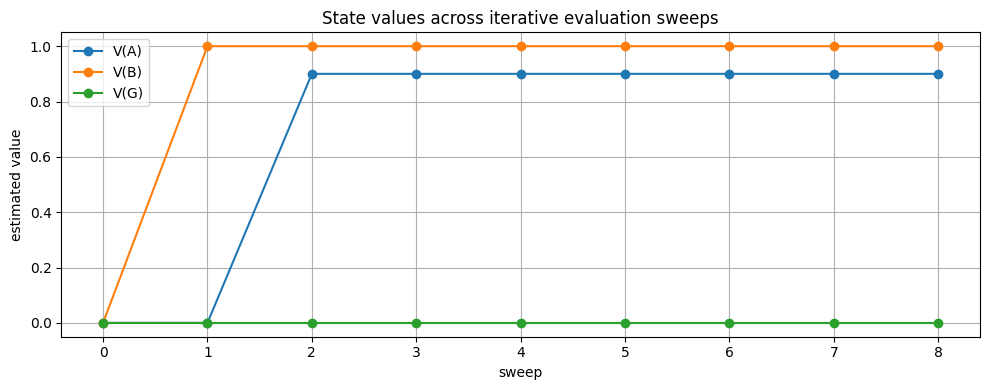

In [7]:
final_values, history = iterative_policy_evaluation(
    states,
    next_state,
    reward,
    gamma=gamma,
    n_sweeps=8,
)

final_values


value_A = [step["A"] for step in history]
value_B = [step["B"] for step in history]
value_G = [step["G"] for step in history]

sweeps = np.arange(len(history))

plt.figure(figsize=(10, 4))
plt.plot(sweeps, value_A, marker="o", label="V(A)")
plt.plot(sweeps, value_B, marker="o", label="V(B)")
plt.plot(sweeps, value_G, marker="o", label="V(G)")
plt.title("State values across iterative evaluation sweeps")
plt.xlabel("sweep")
plt.ylabel("estimated value")
plt.xticks(sweeps)
plt.legend()
plt.tight_layout()
plt.show()


## What if the corridor is much longer?

The three-state corridor is good for intuition because it is easy to hold in your head. But it can also make value propagation look almost too easy. One useful extension is to add many more states between the start and the goal.

That makes the same idea more visible. If the reward is further away, earlier states should still become valuable, but it takes more sweeps for that information to travel backwards through the chain.

In other words: the logic stays the same, but the delay becomes easier to see.


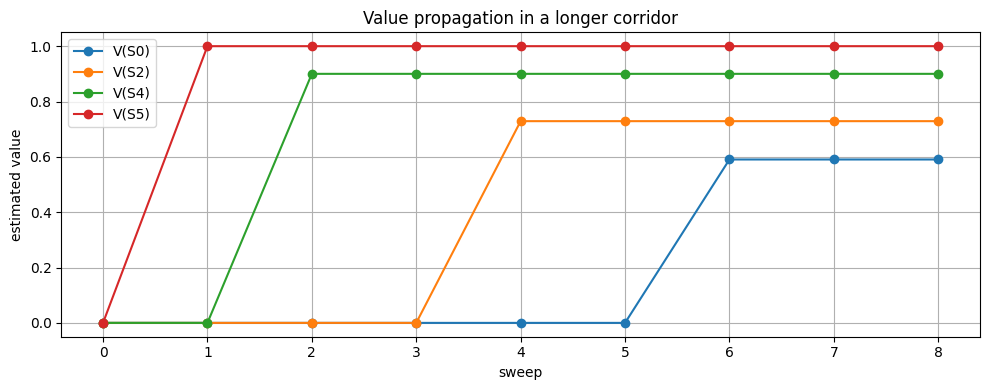

In [12]:
def build_corridor(n_states_before_goal=6):
    """Create a longer deterministic corridor ending in a terminal goal state."""
    corridor_states = [f"S{i}" for i in range(n_states_before_goal)] + ["G"]
    corridor_next_state = {}
    corridor_reward = {}

    for i in range(n_states_before_goal - 1):
        corridor_next_state[f"S{i}"] = f"S{i + 1}"
        corridor_reward[f"S{i}"] = 0.0

    corridor_next_state[f"S{n_states_before_goal - 1}"] = "G"
    corridor_reward[f"S{n_states_before_goal - 1}"] = 1.0
    corridor_next_state["G"] = "G"
    corridor_reward["G"] = 0.0

    return corridor_states, corridor_next_state, corridor_reward


long_states, long_next_state, long_reward = build_corridor(n_states_before_goal=6)
long_values, long_history = iterative_policy_evaluation(
    long_states,
    long_next_state,
    long_reward,
    gamma=0.9,    ######## <-------Change gamma for the exercise!
    n_sweeps=8,
)

plt.figure(figsize=(10, 4))
for state in ["S0", "S2", "S4", "S5"]:
    plt.plot(
        np.arange(len(long_history)),
        [step[state] for step in long_history],
        marker="o",
        label=f"V({state})",
    )

plt.title("Value propagation in a longer corridor")
plt.xlabel("sweep")
plt.ylabel("estimated value")
plt.xticks(np.arange(len(long_history)))
plt.legend()
plt.tight_layout()
plt.show()


## 6. Exercise A: change the discount factor

One of the easiest ways to build intuition for value is to change `gamma` and see what happens.

For this exercise, use the **longer corridor extension** above rather than the original three-state example. That makes the effect easier to see, because the reward has to travel backwards through more states.

In the extended-corridor code cell, try changing `gamma` from `0.9` to:

- `0.5`
- `0.99`

Then ask yourself: what happens to the value of the earlier states, and why? You can focus especially on `S0`, since it is furthest from the reward.

You do not need a long calculation to reason about it. The core idea is enough:

- with a **lower** `gamma`, future rewards are discounted more heavily, so distant rewards matter less
- with a **higher** `gamma`, future rewards keep more of their importance, so earlier states can inherit more value from what comes later

In the longer corridor, the earliest states only become valuable because they eventually lead to reward. That makes this extension a clearer test of what `gamma` is really doing.

This is why `gamma` is such an important quantity in RL. It is not just a technical parameter. It shapes how far ahead the agent is effectively looking.

### What to keep in mind
- lower `gamma` makes the agent more short-term
- higher `gamma` makes the agent more future-oriented
- value depends not only on reward, but also on how much the future counts

<br>
<br>
<hr>
<br>
<br>


# 7. Monte Carlo vs Temporal-Difference Prediction

The first code path in this chapter was about **planning with a known model**. Now we move a step closer to reinforcement learning as it is usually practised: learning from **experience** rather than sweeping over a fully known model.

We will compare two classic ways of learning state values from episodes:

- **Monte Carlo prediction**
- **TD(0) prediction**

They are trying to solve the same problem, but they differ in one crucial respect: **when the update happens**. That timing difference matters a lot. Monte Carlo waits for the final outcome, while TD updates earlier using its current estimate of the next state. That is the historical idea of **bootstrapping**.

So the goal of this section is simple: do not just read the definitions, try to see the learning process unfold step by step.

Here is the same tiny episode in both cases:

```text
A --(reward 0)--> B --(reward +1)--> G
```

Now compare the timing of the updates.

**Monte Carlo**

```text
Step 1: move from A to B
Step 2: move from B to G
Step 3: episode ends
Step 4: only now update the values
```

Monte Carlo waits until the whole story is finished, then looks back at the full return.

**TD(0)**

```text
Step 1: move from A to B, then update A immediately
Step 2: move from B to G, then update B immediately
Step 3: episode ends
```

TD does not wait for the full ending before it starts learning. It uses the reward just seen and its current guess about the next state.

### What to look for
- Monte Carlo learns **after** the episode
- TD learns **during** the episode
- both methods can move towards sensible values
- TD uses an estimate to improve an estimate, which is what bootstrapping means here
- this is one of the historical bridges from dynamic programming to modern RL

<br>
<br>
<hr>
<br>
<br>


In [24]:
def generate_episode():
    """Return one full episode through the tiny corridor."""
    return [
        ("A", 0.0, "B"),
        ("B", 1.0, "G"),
    ]


def mc_prediction(alpha=0.1, n_episodes=20, gamma=0.9):
    """Estimate state values from full returns after each episode."""
    V = {"A": 0.0, "B": 0.0, "G": 0.0}
    history = []

    for _ in range(n_episodes):
        episode = generate_episode()
        G = 0.0
        returns = []

        for (_, r, _) in reversed(episode):
            G = r + gamma * G
            returns.append(G)

        returns.reverse()

        for (s, _, _), g in zip(episode, returns):
            V[s] += alpha * (g - V[s])

        history.append(V.copy())

    return V, history


def td0_prediction(alpha=0.1, n_episodes=20, gamma=0.9):
    """Estimate state values by updating after each transition."""
    V = {"A": 0.0, "B": 0.0, "G": 0.0}
    history = []

    for _ in range(n_episodes):
        for s, r, ns in generate_episode():
            target = r + gamma * V[ns]
            V[s] += alpha * (target - V[s])

        history.append(V.copy())

    return V, history


print("This cell defines the episode generator, Monte Carlo prediction, and TD(0) prediction.")


This cell defines the episode generator, Monte Carlo prediction, and TD(0) prediction.


In [26]:
mc_values, mc_history = mc_prediction(alpha=0.1, n_episodes=20, gamma=0.9)
td_values, td_history = td0_prediction(alpha=0.1, n_episodes=20, gamma=0.9)

print('Monte-Carlo state values after an episode: ', mc_values)
print('Temoporal Difference (TD) state values after an episode: ', td_values)


Monte-Carlo state values after an episode:  {'A': 0.7905810108684878, 'B': 0.8784233454094308, 'G': 0.0}
Temoporal Difference (TD) state values after an episode:  {'A': 0.5474277016873491, 'B': 0.8784233454094308, 'G': 0.0}


## 8. Visual Intuition: how information flows backwards

The timeline comparison above tells us **when** Monte Carlo and TD learn. This section shows what that looks like over repeated episodes.

We will track the estimated values of `A` and `B` under both methods. Since `B` sits right next to reward, it should become sensible fairly quickly. `A` is more interesting, because it only becomes valuable through what lies ahead.

That is where the difference between the two methods becomes easiest to see. If TD really does push information backwards sooner, its estimate for `A` should start improving earlier than Monte Carlo’s.

### What to look for
- `B` usually learns quickly because it is closest to reward
- `A` has to inherit value indirectly
- TD often starts pushing value back towards `A` sooner
- both methods are heading towards the same broad target, but the learning path looks different

<br>
<br>
<hr>
<br>
<br>


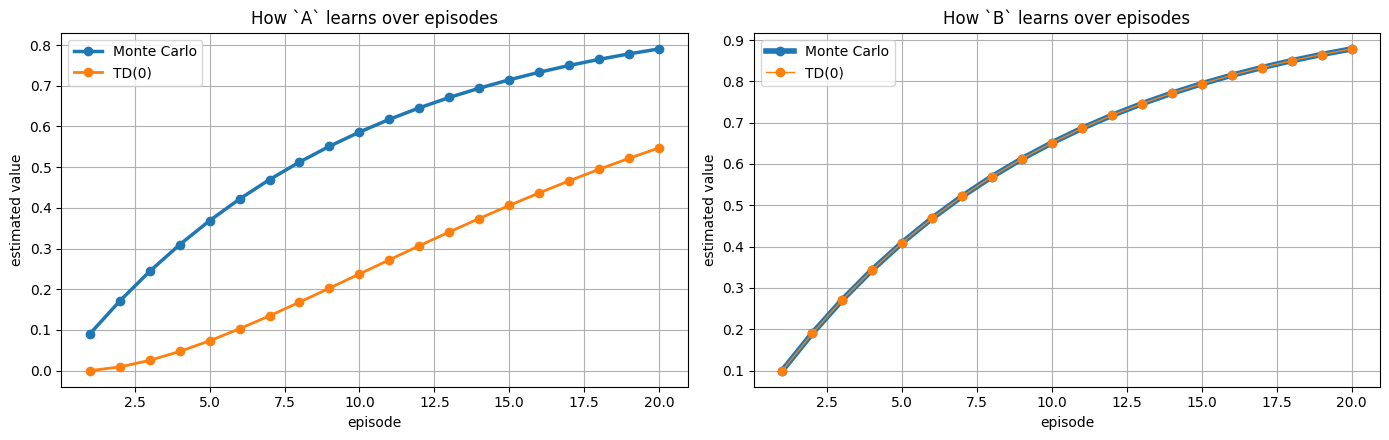

In [32]:
episodes = np.arange(1, len(mc_history) + 1)

mc_A = [step["A"] for step in mc_history]
mc_B = [step["B"] for step in mc_history]
td_A = [step["A"] for step in td_history]
td_B = [step["B"] for step in td_history]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

axs[0].plot(episodes, mc_A, marker="o", linewidth=2.5, zorder=3, label="Monte Carlo")
axs[0].plot(episodes, td_A, marker="o", linewidth=2.0, zorder=2, label="TD(0)")
axs[0].set_title("How `A` learns over episodes")
axs[0].set_xlabel("episode")
axs[0].set_ylabel("estimated value")
axs[0].legend()

axs[1].plot(episodes, mc_B, marker="o", linewidth=4.0, zorder=2, label="Monte Carlo")
axs[1].plot(episodes, td_B, marker="o", linewidth=1.0, zorder=3, label="TD(0)")
axs[1].set_title("How `B` learns over episodes")
axs[1].set_xlabel("episode")
axs[1].set_ylabel("estimated value")
axs[1].legend()

plt.tight_layout()
plt.show()


### What you should notice
- `B` is easy to value because it sits one step away from the reward
- `A` is harder because its value has to come through `B`
- Monte Carlo can only adjust after seeing the full episode return
- TD can start pushing value backwards sooner, because it updates from the next-state estimate immediately

This is the first place in the notebook where the phrase **bootstrapping** should feel concrete rather than abstract. TD is not waiting for the whole future to arrive. It is using its current estimate of the future to start learning now.

That small change in update timing turns out to be one of the most important ideas in the history of RL.

<br>
<br>
<hr>
<br>
<br>


## 9. Diving Deeper

By this point, the main storyline of the chapter should be visible. Bellman gave us the recursive lens. Dynamic programming showed how to compute with it when the model is known. Monte Carlo showed how to learn from complete sampled returns. TD showed how to learn earlier, by combining sampling with bootstrapping.

This section slows down and makes that sequence explicit. The goal is not to introduce a lot of new machinery. It is to make the historical structure of the chapter feel coherent.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.1 Bellman and recursive value

Bellman’s major contribution was not just a specific algorithm. It was the recognition that sequential decision problems have a recursive structure. The value of a state can be written in terms of immediate reward and the value of what comes next.

That idea may sound modest, but it changed the whole shape of the problem. Instead of reasoning about a long future all at once, you can break the problem into linked local pieces. In RL, that is one of the deepest ideas in the entire field.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.2 Dynamic programming

Dynamic programming assumes a known model:

- the transition structure is known
- the rewards are known
- values can be updated by sweeping across the state space directly

That is what made the earlier corridor example a planning problem. We were not discovering the world through trial and error. We were computing over a world we already understood.

This is powerful, but also limited. In real problems, the model is often unknown, too large, or too messy to work with directly. That is where the later learning methods become important.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.3 Monte Carlo methods

Monte Carlo methods replace full model knowledge with sampled experience. Instead of sweeping over all states using known transitions, they estimate value by averaging what happens over complete episodes.

That gives Monte Carlo a very natural appeal:

- it is conceptually simple
- it does not need a model of the environment
- it learns from actual outcomes

But it also has a clear limitation: it must wait until the episode finishes before it can use the full return.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.4 Temporal-difference learning

TD learning was a major step because it combines two things at once:

- sampling from experience
- bootstrapping from current value estimates

The canonical TD(0) update is:

$$
V(s) \leftarrow V(s) + \alpha \left[r + \gamma V(s') - V(s)\right]
$$

This has the update shape that appears again and again in RL:

- old estimate
- plus step-size
- times a prediction error

That is one reason TD is so important historically. It keeps the recursive Bellman spirit, but turns it into a practical learning rule.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.5 Why this historical sequence matters

The field did not develop randomly:

- Bellman gave the recursive way of thinking
- dynamic programming showed how to compute with it when the model is known
- Monte Carlo showed how to learn from full sampled returns
- TD showed how to learn online with bootstrapping

Modern RL still lives inside that structure. Even when the algorithms become larger and the environments become harder, these same ideas keep returning.

<br>
<br>
<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">
<br>
<br>

### 9.6 If you want to go deeper

- Richard Bellman, *Dynamic Programming*
- Sutton & Barto (2018), Chapters 3 to 6
- David Silver’s RL lectures on dynamic programming, Monte Carlo methods, and TD learning

<br>
<br>
<hr>
<br>
<br>


## 10. Final Visual Example: watching value spread through a gridworld

The corridor helped us see the basic idea. The Monte Carlo versus TD comparison helped us see the difference in update timing. But both examples are still extremely small. A final visual example can make the chapter’s main ideas feel more concrete.

So instead of ending with prose alone, we finish with a slightly richer environment: a small square **gridworld** with a goal.

The idea is simple:

- the agent starts somewhere in the grid
- one square is the goal
- the goal gives reward `+1`
- other squares give reward `0`
- the episode ends when the goal is reached

That environment is still small enough to understand at a glance, but it is large enough to make value look spatial rather than purely symbolic. Instead of talking about one state after another, we can literally watch useful regions of the environment become more valuable over time.

### What you should notice
- states near the goal become meaningful first
- earlier states only become valuable because they lead towards reward
- both methods move in the same broad direction
- TD often spreads useful structure sooner because it bootstraps

<br>
<br>
<hr>
<br>
<br>


In [4]:
from IPython.display import clear_output, display

GRID_ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]


def initialise_grid_values(grid_size, goal):
    """Create a zero-valued grid for all non-terminal states."""
    return {
        (row, col): 0.0
        for row in range(grid_size)
        for col in range(grid_size)
        if (row, col) != goal
    }


def valid_moves(state, grid_size):
    """Return all valid one-step moves from the current state."""
    row, col = state
    moves = []

    for d_row, d_col in GRID_ACTIONS:
        new_row = row + d_row
        new_col = col + d_col

        if 0 <= new_row < grid_size and 0 <= new_col < grid_size:
            moves.append((new_row, new_col))

    return moves


def generate_grid_episode(grid_size=5, start=(0, 0), goal=None, max_steps=60, rng=None):
    """Sample one random episode in the gridworld."""
    if goal is None:
        goal = (grid_size - 1, grid_size - 1)

    if rng is None:
        rng = np.random.default_rng()

    state = start
    episode = []

    for _ in range(max_steps):
        next_state = valid_moves(state, grid_size)[rng.integers(len(valid_moves(state, grid_size)))]
        reward = 1.0 if next_state == goal else 0.0
        episode.append((state, reward, next_state))
        state = next_state

        if state == goal:
            break

    return episode


def mc_grid_prediction(values, episode, alpha=0.1, gamma=0.9):
    """Monte Carlo update from the full return of one episode."""
    G = 0.0
    returns = []

    for (_, reward, _) in reversed(episode):
        G = reward + gamma * G
        returns.append(G)

    returns.reverse()

    for (state, _, _), full_return in zip(episode, returns):
        values[state] += alpha * (full_return - values[state])


def td0_grid_prediction(values, episode, alpha=0.1, gamma=0.9, goal=None):
    """TD(0) update after each transition in the episode."""
    for state, reward, next_state in episode:
        next_value = 0.0 if next_state == goal else values[next_state]
        target = reward + gamma * next_value
        values[state] += alpha * (target - values[state])


def values_to_grid(values, grid_size, goal):
    """Convert a state-value dictionary into a 2D grid for plotting."""
    grid = np.zeros((grid_size, grid_size))

    for (row, col), value in values.items():
        grid[row, col] = value

    grid[goal] = 1.0
    return grid


def draw_value_heatmaps(axs, mc_values, td_values, grid_size, start, goal, episode_number):
    """Draw side-by-side heatmaps for Monte Carlo and TD values."""
    mc_grid = values_to_grid(mc_values, grid_size, goal)
    td_grid = values_to_grid(td_values, grid_size, goal)

    titles = [
        f"Monte Carlo after episode {episode_number}",
        f"TD(0) after episode {episode_number}",
    ]

    last_image = None
    for ax, grid, title in zip(axs, [mc_grid, td_grid], titles):
        ax.clear()
        last_image = ax.imshow(grid, cmap="coolwarm", vmin=0.0, vmax=1.0)
        ax.set_title(title)
        ax.set_xticks(range(grid_size))
        ax.set_yticks(range(grid_size))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.text(start[1], start[0], "S", ha="center", va="center", fontsize=12, weight="bold", color="black")
        ax.text(goal[1], goal[0], "G", ha="center", va="center", fontsize=12, weight="bold", color="black")

    return last_image


def animate_gridworld_learning(
    n_episodes=20,
    grid_size=5,
    start=(0, 0),
    goal=None,
    alpha=0.1,
    gamma=0.9,
    pause=0.3,
    max_steps=60,
    seed=7,
):
    """Animate Monte Carlo and TD value learning on the same gridworld episodes."""
    if goal is None:
        goal = (grid_size - 1, grid_size - 1)

    rng = np.random.default_rng(seed)
    mc_values = initialise_grid_values(grid_size, goal)
    td_values = initialise_grid_values(grid_size, goal)

    fig, axs = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
    image = draw_value_heatmaps(axs, mc_values, td_values, grid_size, start, goal, episode_number=0)
    colourbar = fig.colorbar(image, ax=axs, fraction=0.046, pad=0.04)
    colourbar.set_label("estimated value")

    interactive_backend = "agg" not in plt.get_backend().lower()

    if interactive_backend:
        display(fig)
        plt.pause(pause)

    for episode_number in range(1, n_episodes + 1):
        episode = generate_grid_episode(
            grid_size=grid_size,
            start=start,
            goal=goal,
            max_steps=max_steps,
            rng=rng,
        )

        mc_grid_prediction(mc_values, episode, alpha=alpha, gamma=gamma)
        td0_grid_prediction(td_values, episode, alpha=alpha, gamma=gamma, goal=goal)

        draw_value_heatmaps(axs, mc_values, td_values, grid_size, start, goal, episode_number)

        if interactive_backend:
            clear_output(wait=True)
            display(fig)
            plt.pause(pause)

    plt.close(fig)
    return mc_values, td_values


print("This cell defines the gridworld environment and the animated Monte Carlo versus TD heatmaps.")


This cell defines the gridworld environment and the animated Monte Carlo versus TD heatmaps.


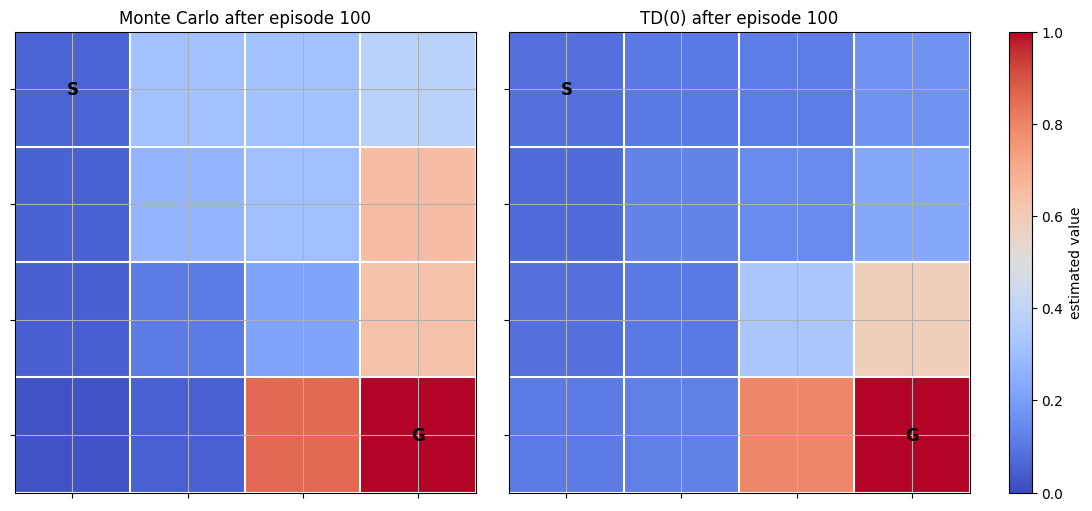

In [15]:
mc_grid_values, td_grid_values = animate_gridworld_learning(
    n_episodes=100,
    grid_size=4,
    alpha=0.4,
    gamma=0.9,
    pause=0.00001,
    seed=7,
)

### Gridworld Conclusion
- value is now something you can see spread across space, not just along a tiny corridor
- the goal state acts like a source of useful value for nearby states
- both methods gradually organise the grid in a sensible way
- TD often develops that structure sooner because it bootstraps from the next state immediately

<br>
<br>
<hr>
<br>
<br>


## 11. Knowledge Check

### Concept checks (answers at the bottom of the notebook)
1. Why was Bellman’s recursive way of thinking such an important step for reinforcement learning?
2. What is the key difference between dynamic programming and learning directly from experience?
3. In your own words, what does it mean to say that TD learning **bootstraps**?
4. Why can a state with reward `0` still have positive value?
5. In the Monte Carlo versus TD comparison, what is the most important difference in **when** the update happens?

### Small coding change
- In the gridworld example, move the goal to a different square. How does the heatmap change, and which regions of the grid become valuable first?

### Extension
- Increase the grid size and compare how long it takes Monte Carlo and TD to spread useful value information through the environment. Does the visual difference between the two methods become clearer?

<br>
<br>
<hr>
<br>
<br>


## 12. Takeaways
- reinforcement learning grew out of several older traditions, especially control, dynamic programming, and trial-and-error learning
- Bellman’s recursive view is one of the central ideas behind almost all RL methods
- dynamic programming is about planning when the model is known
- Monte Carlo and TD are both ways of learning from experience, but they differ in when they update
- TD introduced bootstrapping, which is one of the key ideas that continues through modern RL

<br>
<br>
<hr>
<br>
<br>


## 13. What’s Next
- Next notebook: **RL loop + vocabulary** so we can move from historical foundations into the standard language of states, actions, rewards, returns, policies, and values.
- Suggested reading: Sutton & Barto (2018), Chapters 3 to 6, if you want a more formal treatment of Bellman equations, dynamic programming, Monte Carlo methods, and TD learning.

<br>
<br>
<hr>
<br>
<br>


## Answers to Concept Checks

### 1. Why was Bellman’s recursive way of thinking such an important step for reinforcement learning?
Because it made long-run decision problems easier to reason about. Instead of treating the whole future as one huge object, it let us write value in terms of immediate reward plus the value of what comes next. That recursive structure is what makes dynamic programming, TD learning, and many later RL methods possible.

### 2. What is the key difference between dynamic programming and learning directly from experience?
Dynamic programming assumes the model is known, so you can sweep across states and compute updates directly. Learning from experience does not assume that full model knowledge. Instead, it improves values from sampled episodes or transitions.

### 3. In your own words, what does it mean to say that TD learning **bootstraps**?
It means TD uses its current estimate of the next state to improve the current state right away. In other words, it uses an estimate to improve an estimate, rather than waiting for the full final return.

### 4. Why can a state with reward `0` still have positive value?
Because value depends on future consequences, not just immediate reward. A state can be valuable if it leads to other states that eventually produce reward.

### 5. In the Monte Carlo versus TD comparison, what is the most important difference in **when** the update happens?
Monte Carlo waits until the episode has finished and then updates from the full return. TD updates during the episode, immediately after each transition.

<br>
<br>
<hr>
<br>
<br>
